# ...........IEEE-CIS Fraud Detection
# Notebook 01: Data Understanding

Author: BYNADGE JOSEPH JAKARASI

Project:
JustCorp Sentinel AI
Explainable Financial Fraud Detection Platform

---

## Purpose

This notebook performs the initial exploration of the IEEE-CIS Fraud Detection dataset. Before any preprocessing or machine learning, it is essential to understand the structure, characteristics, and quality of the available data.

Understanding the dataset at this stage helps identify potential data quality issues, determine appropriate preprocessing strategies, and establish the foundation for subsequent exploratory analysis and predictive modelling.

---

## Objectives

This notebook aims to:

• Load the transaction and identity datasets.

• Merge both datasets into a single analytical dataset.

• Understand dataset dimensions.

• Identify the target variable.

• Examine class imbalance.

• Identify numerical and categorical variables.

• Evaluate missing values.

• Generate an initial understanding of the fraud prediction problem.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [3]:
train_transaction_path = "../../data/raw/train_transaction.csv"
train_identity_path = "../../data/raw/train_identity.csv"

transaction_df = pd.read_csv(train_transaction_path)
identity_df = pd.read_csv(train_identity_path)

print("Transaction shape:", transaction_df.shape)
print("Identity shape:", identity_df.shape)

Transaction shape: (590540, 394)
Identity shape: (144233, 41)


In [4]:
fraud_df = transaction_df.merge(
    identity_df,
    on="TransactionID",
    how="left"
)

print("Merged dataset shape:", fraud_df.shape)
print("Target column exists:", "isFraud" in fraud_df.columns)
fraud_df.head()

Merged dataset shape: (590540, 434)
Target column exists: True


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,M0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,debit,330.0,87.0,287.0,NaN,outlook.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,315.0,NaN,NaN,NaN,315.0,T,T,T,M0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,debit,476.0,87.0,NaN,NaN,yahoo.com,NaN,2.0,5.0,0.0,0.0,0.0,4.0,0.0,0.0,1.0,0.0,1.0,0.0,25.0,1.0,112.0,112.0,0.0,94.0,0.0,NaN,NaN,NaN,NaN,84.0,NaN,NaN,NaN,NaN,111.0,NaN,NaN,NaN,M0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,credit,420.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0,NotFound,NaN,-480.0,New,NotFound,166.0,NaN,542.0,144.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,Android 7.0,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


In [5]:
fraud_counts = fraud_df["isFraud"].value_counts()
fraud_percentages = fraud_df["isFraud"].value_counts(normalize=True) * 100

summary = pd.DataFrame({
    "count": fraud_counts,
    "percentage": fraud_percentages.round(2)
})

summary

,count,percentage
isFraud,,
0,569877,96.5
1,20663,3.5


In [6]:
# Dataset dimensions
print(f"Number of observations : {fraud_df.shape[0]:,}")
print(f"Number of variables    : {fraud_df.shape[1]:,}")

Number of observations : 590,540
Number of variables    : 434


In [7]:
# Dataset information
fraud_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 434 entries, TransactionID to DeviceInfo
dtypes: float64(399), int64(4), str(31)
memory usage: 1.9 GB


In [8]:
# Data types
fraud_df.dtypes.value_counts()

float64    399
str         31
int64        4
Name: count, dtype: int64

In [9]:
# Statistical summary of numerical variables
fraud_df.describe().T

,count,mean,std,min,25%,50%,75%,max
TransactionID,590540.0,3.282270e+06,1.704744e+05,2987000.000,3134634.750,3282269.500,3429904.25,3.577539e+06
isFraud,590540.0,3.499001e-02,1.837546e-01,0.000,0.000,0.000,0.00,1.000000e+00
TransactionDT,590540.0,7.372311e+06,4.617224e+06,86400.000,3027057.750,7306527.500,11246620.00,1.581113e+07
TransactionAmt,590540.0,1.350272e+02,2.391625e+02,0.251,43.321,68.769,125.00,3.193739e+04
card1,590540.0,9.898735e+03,4.901170e+03,1000.000,6019.000,9678.000,14184.00,1.839600e+04
...,...,...,...,...,...,...,...,...
id_22,5169.0,1.600271e+01,6.897665e+00,10.000,14.000,14.000,14.00,4.400000e+01
id_24,4747.0,1.280093e+01,2.372447e+00,11.000,11.000,11.000,15.00,2.600000e+01
id_25,5132.0,3.296089e+02,9.746109e+01,100.000,321.000,321.000,371.00,5.480000e+02
id_26,5163.0,1.490703e+02,3.210199e+01,100.000,119.000,149.000,169.00,2.160000e+02


In [10]:
# Missing values
missing = fraud_df.isnull().sum().sort_values(ascending=False)
missing_percent = (missing / len(fraud_df)) * 100

missing_df = pd.DataFrame({
    "Missing Values": missing,
    "Percentage (%)": missing_percent
})

missing_df.head(30)

,Missing Values,Percentage (%)
id_24,585793,99.196159
id_25,585408,99.130965
id_07,585385,99.127070
id_08,585385,99.127070
id_21,585381,99.126393
id_26,585377,99.125715
id_27,585371,99.124699
id_23,585371,99.124699
id_22,585371,99.124699
dist2,552913,93.628374


In [11]:
# Columns with more than 90% missing values
high_missing_cols = missing_df[missing_df["Percentage (%)"] > 90]

print("Number of columns with >90% missing values:", high_missing_cols.shape[0])
high_missing_cols

Number of columns with >90% missing values: 12


,Missing Values,Percentage (%)
id_24,585793,99.196159
id_25,585408,99.130965
id_07,585385,99.127070
id_08,585385,99.127070
id_21,585381,99.126393
id_26,585377,99.125715
id_27,585371,99.124699
id_23,585371,99.124699
id_22,585371,99.124699
dist2,552913,93.628374


In [12]:
# Missing value distribution summary
missing_df["Percentage (%)"].describe()

count    434.000000
mean      45.074372
std       36.543232
min        0.000000
25%        0.266282
50%       47.293494
75%       77.913435
max       99.196159
Name: Percentage (%), dtype: float64

In [13]:
# Count columns by missingness bands
missing_bands = pd.cut(
    missing_df["Percentage (%)"],
    bins=[-1, 0, 25, 50, 75, 90, 100],
    labels=["0%", "1-25%", "26-50%", "51-75%", "76-90%", "91-100%"]
)

missing_band_summary = missing_bands.value_counts().sort_index()
missing_band_summary

Percentage (%)
0%          20
1-25%      162
26-50%      38
51-75%       6
76-90%     196
91-100%     12
Name: count, dtype: int64

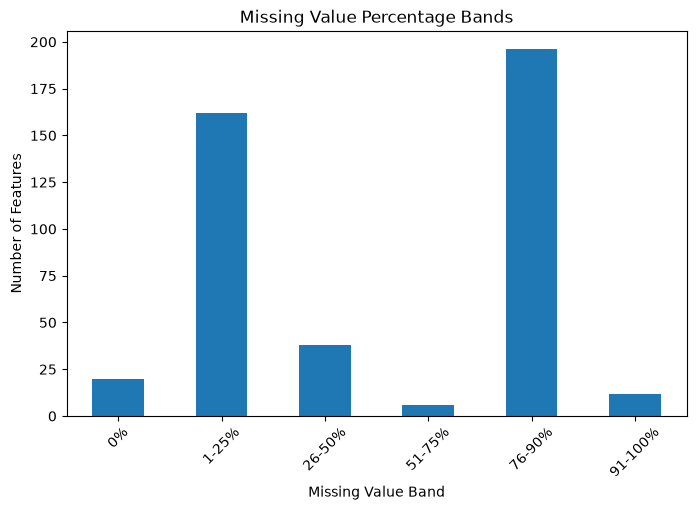

In [14]:
plt.figure(figsize=(8, 5))
missing_band_summary.plot(kind="bar")
plt.title("Missing Value Percentage Bands")
plt.xlabel("Missing Value Band")
plt.ylabel("Number of Features")
plt.xticks(rotation=45)
plt.show()

In [15]:
# Separate numerical and categorical columns
numeric_cols = fraud_df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = fraud_df.select_dtypes(include=["object", "str"]).columns.tolist()

print("Number of numerical columns:", len(numeric_cols))
print("Number of categorical columns:", len(categorical_cols))

Number of numerical columns: 403
Number of categorical columns: 31


In [16]:
# Display categorical columns
categorical_cols

['ProductCD',
 'card4',
 'card6',
 'P_emaildomain',
 'R_emaildomain',
 'M1',
 'M2',
 'M3',
 'M4',
 'M5',
 'M6',
 'M7',
 'M8',
 'M9',
 'id_12',
 'id_15',
 'id_16',
 'id_23',
 'id_27',
 'id_28',
 'id_29',
 'id_30',
 'id_31',
 'id_33',
 'id_34',
 'id_35',
 'id_36',
 'id_37',
 'id_38',
 'DeviceType',
 'DeviceInfo']

In [17]:
# Cardinality of categorical variables
cat_cardinality = fraud_df[categorical_cols].nunique().sort_values(ascending=False)

cat_cardinality_df = pd.DataFrame({
    "Unique Values": cat_cardinality
})

cat_cardinality_df

,Unique Values
DeviceInfo,1786
id_33,260
id_31,130
id_30,75
R_emaildomain,60
P_emaildomain,59
ProductCD,5
card6,4
card4,4
id_34,4


In [18]:
# Fraud rate by ProductCD
product_fraud = fraud_df.groupby("ProductCD")["isFraud"].agg(["count", "sum", "mean"]).sort_values("mean", ascending=False)
product_fraud["fraud_rate_%"] = (product_fraud["mean"] * 100).round(2)
product_fraud

,count,sum,mean,fraud_rate_%
ProductCD,,,,
C,68519,8008,0.116873,11.69
S,11628,686,0.058996,5.90
H,33024,1574,0.047662,4.77
R,37699,1426,0.037826,3.78
W,439670,8969,0.020399,2.04


In [19]:
# Fraud rate by card type
card4_fraud = fraud_df.groupby("card4")["isFraud"].agg(["count", "sum", "mean"]).sort_values("mean", ascending=False)
card4_fraud["fraud_rate_%"] = (card4_fraud["mean"] * 100).round(2)
card4_fraud

,count,sum,mean,fraud_rate_%
card4,,,,
discover,6651,514,0.077282,7.73
visa,384767,13373,0.034756,3.48
mastercard,189217,6496,0.034331,3.43
american express,8328,239,0.028698,2.87


In [20]:
# Fraud rate by card6
card6_fraud = fraud_df.groupby("card6")["isFraud"].agg(["count", "sum", "mean"]).sort_values("mean", ascending=False)
card6_fraud["fraud_rate_%"] = (card6_fraud["mean"] * 100).round(2)
card6_fraud

,count,sum,mean,fraud_rate_%
card6,,,,
credit,148986,9950,0.066785,6.68
debit,439938,10674,0.024263,2.43
charge card,15,0,0.000000,0.00
debit or credit,30,0,0.000000,0.00


In [21]:
# Transaction amount summary by fraud status
amount_summary = fraud_df.groupby("isFraud")["TransactionAmt"].describe()
amount_summary

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,569877.0,134.511665,239.395078,0.251,43.970,68.5,120.0,31937.391
1,20663.0,149.244779,232.212163,0.292,35.044,75.0,161.0,5191.000


In [22]:
# Median transaction amount by fraud status
fraud_df.groupby("isFraud")["TransactionAmt"].median()

isFraud
0    68.5
1    75.0
Name: TransactionAmt, dtype: float64

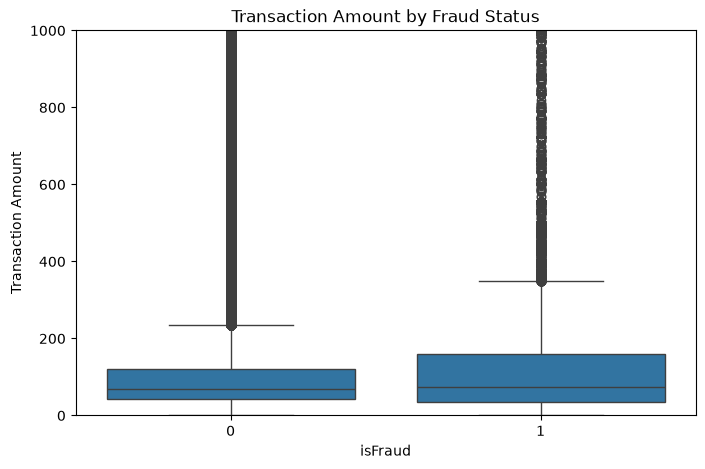

In [23]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=fraud_df, x="isFraud", y="TransactionAmt")
plt.title("Transaction Amount by Fraud Status")
plt.xlabel("isFraud")
plt.ylabel("Transaction Amount")
plt.ylim(0, 1000)
plt.show()

In [24]:
fraud_df.groupby("isFraud")["TransactionAmt"].median()

isFraud
0    68.5
1    75.0
Name: TransactionAmt, dtype: float64

In [25]:
fraud_df["TransactionDay"] = fraud_df["TransactionDT"] / (60 * 60 * 24)
fraud_df["TransactionWeek"] = fraud_df["TransactionDay"] / 7

fraud_df[["TransactionDT", "TransactionDay", "TransactionWeek"]].head()

C:\Users\USER\AppData\Local\Temp\ipykernel_12584\2056438831.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  fraud_df["TransactionDay"] = fraud_df["TransactionDT"] / (60 * 60 * 24)
C:\Users\USER\AppData\Local\Temp\ipykernel_12584\2056438831.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  fraud_df["TransactionWeek"] = fraud_df["TransactionDay"] / 7


,TransactionDT,TransactionDay,TransactionWeek
0,86400,1.000000,0.142857
1,86401,1.000012,0.142859
2,86469,1.000799,0.142971
3,86499,1.001146,0.143021
4,86506,1.001227,0.143032


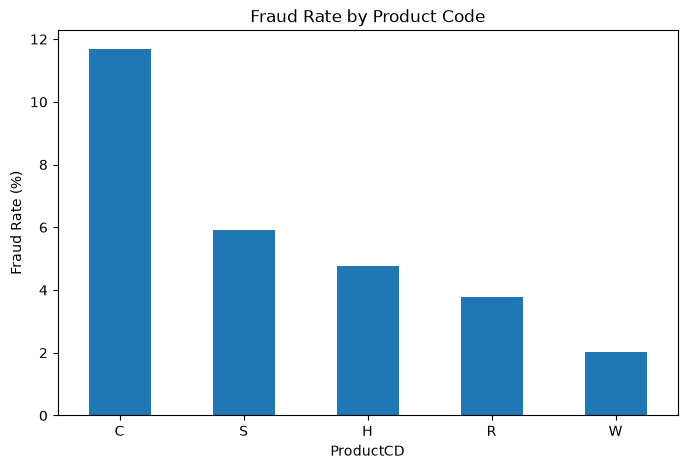

In [26]:
plt.figure(figsize=(8, 5))
product_fraud["fraud_rate_%"].plot(kind="bar")
plt.title("Fraud Rate by Product Code")
plt.xlabel("ProductCD")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [27]:
# Fraud rate by transaction week
weekly_fraud = fraud_df.groupby(fraud_df["TransactionWeek"].astype(int))["isFraud"].agg(["count", "sum", "mean"])
weekly_fraud["fraud_rate_%"] = (weekly_fraud["mean"] * 100).round(2)

weekly_fraud.head()

,count,sum,mean,fraud_rate_%
TransactionWeek,,,,
0,23810,668,0.028055,2.81
1,27803,727,0.026148,2.61
2,34470,879,0.025500,2.55
3,37251,690,0.018523,1.85
4,24041,919,0.038226,3.82


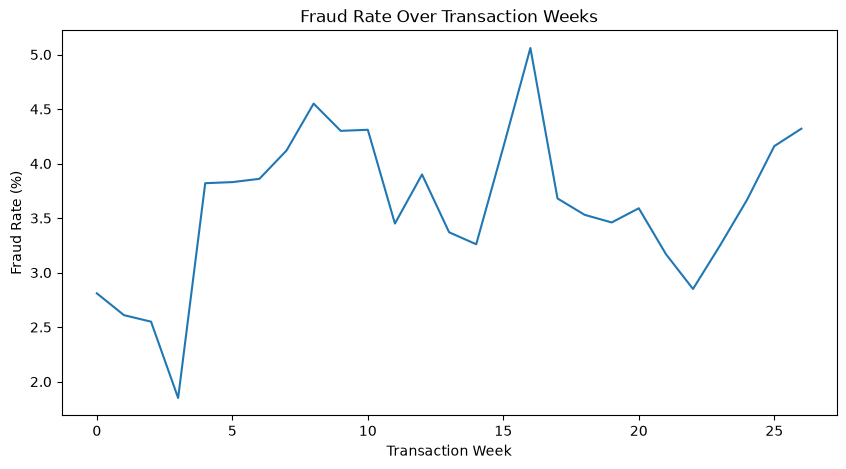

In [28]:
plt.figure(figsize=(10, 5))
weekly_fraud["fraud_rate_%"].plot()
plt.title("Fraud Rate Over Transaction Weeks")
plt.xlabel("Transaction Week")
plt.ylabel("Fraud Rate (%)")
plt.show()

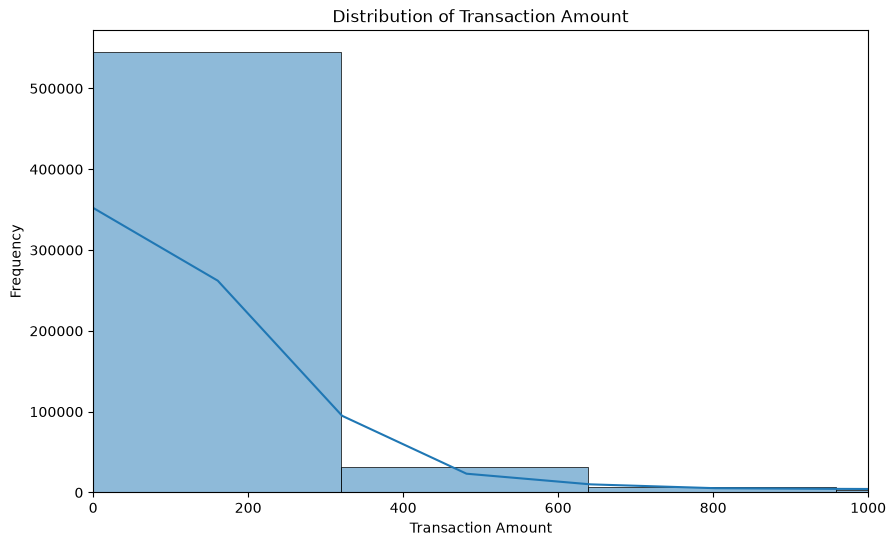

In [29]:
##Transaction Amount Distribution
plt.figure(figsize=(10,6))

sns.histplot(
    fraud_df["TransactionAmt"],
    bins=100,
    kde=True
)

plt.xlim(0,1000)
plt.title("Distribution of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

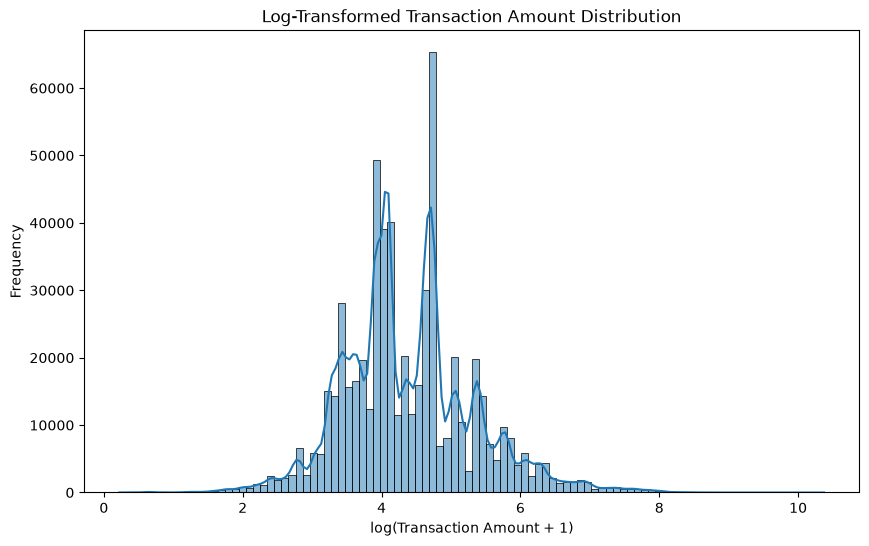

In [30]:
##Log Transformation
plt.figure(figsize=(10,6))

sns.histplot(
    np.log1p(fraud_df["TransactionAmt"]),
    bins=100,
    kde=True
)

plt.title("Log-Transformed Transaction Amount Distribution")
plt.xlabel("log(Transaction Amount + 1)")
plt.ylabel("Frequency")

plt.show()

In [31]:
fraud_df["ProductCD"].value_counts()

ProductCD
W    439670
C     68519
R     37699
H     33024
S     11628
Name: count, dtype: int64

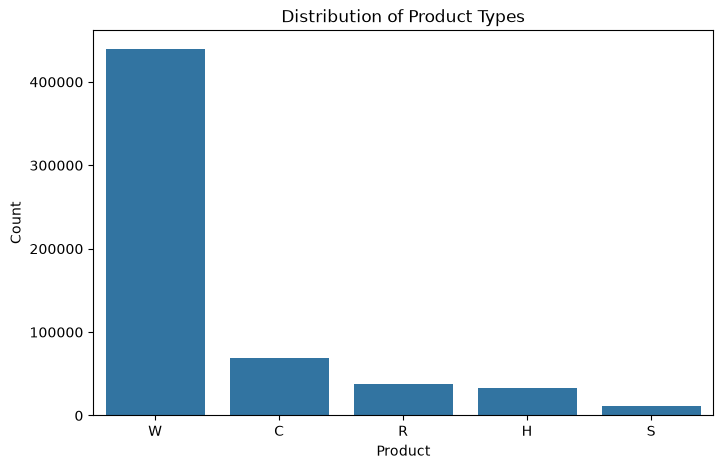

In [32]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=fraud_df,
    x="ProductCD",
    order=fraud_df["ProductCD"].value_counts().index
)

plt.title("Distribution of Product Types")
plt.xlabel("Product")
plt.ylabel("Count")

plt.show()

In [33]:
##Card Network Distribution
fraud_df["card4"].value_counts()

card4
visa                384767
mastercard          189217
american express      8328
discover              6651
Name: count, dtype: int64

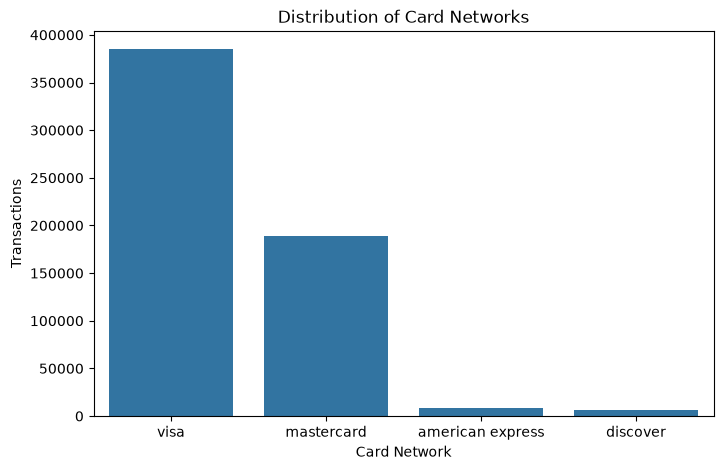

In [34]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=fraud_df,
    x="card4",
    order=fraud_df["card4"].value_counts().index
)

plt.title("Distribution of Card Networks")
plt.xlabel("Card Network")
plt.ylabel("Transactions")

plt.show()

In [35]:
fraud_df["card6"].value_counts()

card6
debit              439938
credit             148986
debit or credit        30
charge card            15
Name: count, dtype: int64

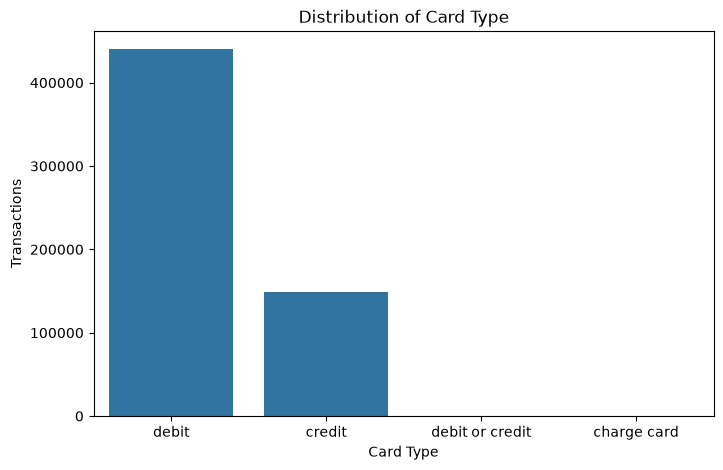

In [36]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=fraud_df,
    x="card6",
    order=fraud_df["card6"].value_counts().index
)

plt.title("Distribution of Card Type")
plt.xlabel("Card Type")
plt.ylabel("Transactions")

plt.show()

In [37]:
# Top purchaser email domains
fraud_df["P_emaildomain"].value_counts().head(20)

P_emaildomain
gmail.com        228355
yahoo.com        100934
hotmail.com       45250
anonymous.com     36998
aol.com           28289
comcast.net        7888
icloud.com         6267
outlook.com        5096
msn.com            4092
att.net            4033
live.com           3041
sbcglobal.net      2970
verizon.net        2705
ymail.com          2396
bellsouth.net      1909
yahoo.com.mx       1543
me.com             1522
cox.net            1393
optonline.net      1011
charter.net         816
Name: count, dtype: int64

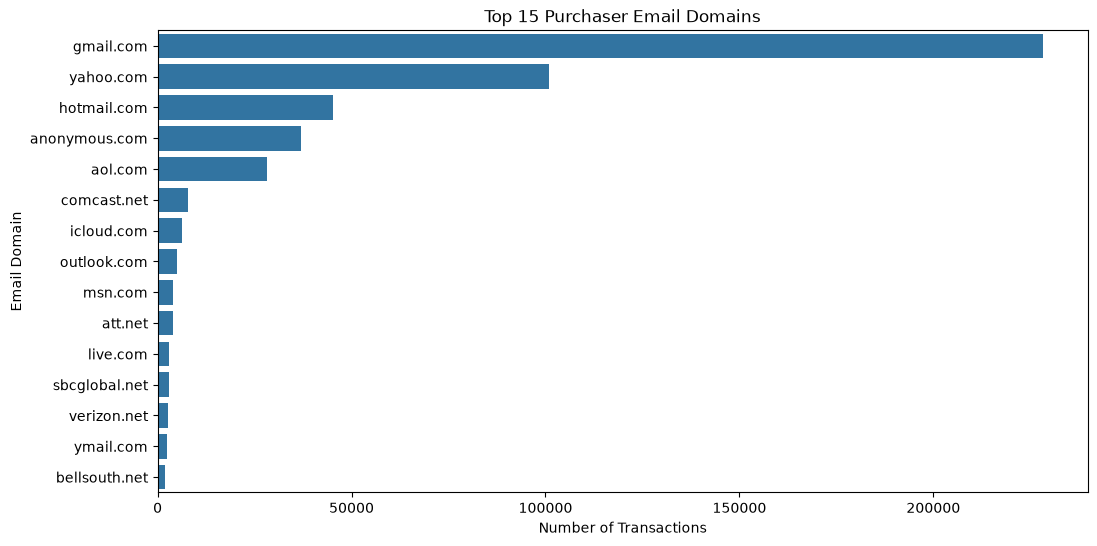

In [38]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=fraud_df,
    y="P_emaildomain",
    order=fraud_df["P_emaildomain"].value_counts().head(15).index
)

plt.title("Top 15 Purchaser Email Domains")
plt.xlabel("Number of Transactions")
plt.ylabel("Email Domain")

plt.show()

In [39]:
fraud_df["R_emaildomain"].value_counts().head(20)

R_emaildomain
gmail.com        57147
hotmail.com      27509
anonymous.com    20529
yahoo.com        11842
aol.com           3701
outlook.com       2507
comcast.net       1812
yahoo.com.mx      1508
icloud.com        1398
msn.com            852
live.com           762
live.com.mx        754
verizon.net        620
me.com             556
sbcglobal.net      552
cox.net            459
outlook.es         433
att.net            430
bellsouth.net      422
hotmail.fr         293
Name: count, dtype: int64

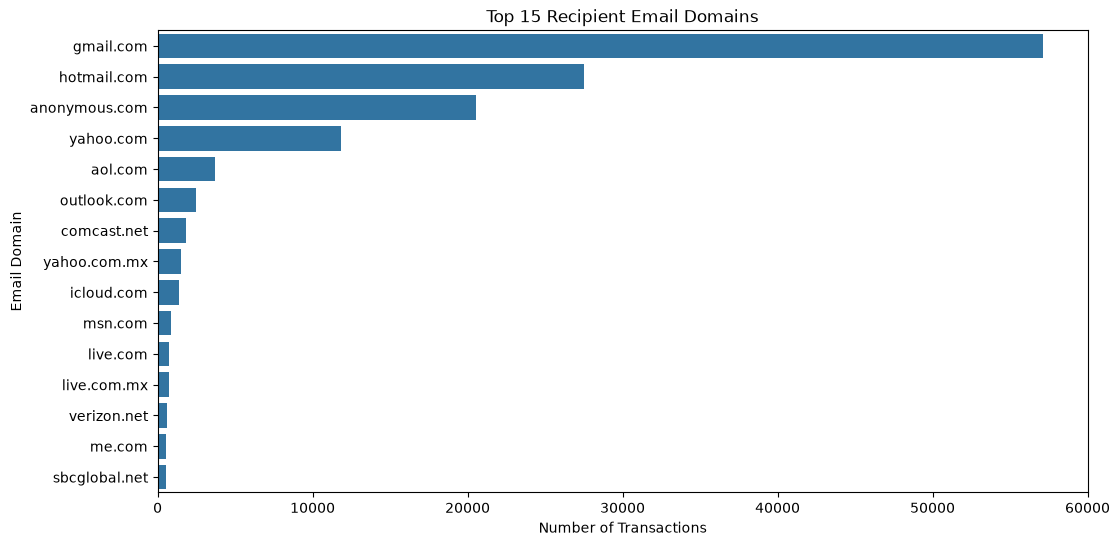

In [40]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=fraud_df,
    y="R_emaildomain",
    order=fraud_df["R_emaildomain"].value_counts().head(15).index
)

plt.title("Top 15 Recipient Email Domains")
plt.xlabel("Number of Transactions")
plt.ylabel("Email Domain")

plt.show()

In [41]:
fraud_df["DeviceType"].value_counts(dropna=False)

DeviceType
NaN        449730
desktop     85165
mobile      55645
Name: count, dtype: int64

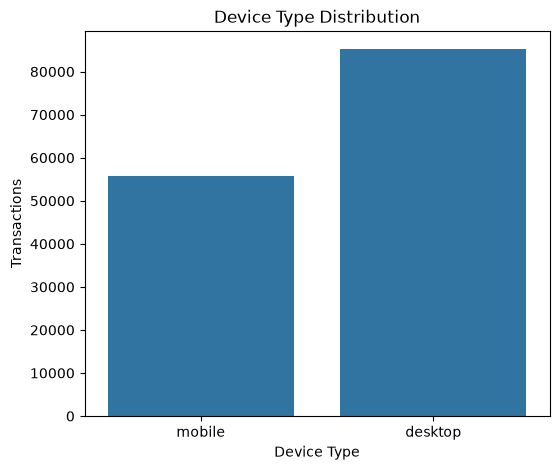

In [42]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=fraud_df,
    x="DeviceType"
)

plt.title("Device Type Distribution")
plt.xlabel("Device Type")
plt.ylabel("Transactions")

plt.show()

In [43]:
fraud_df["DeviceInfo"].value_counts().head(20)

DeviceInfo
Windows                        47722
iOS Device                     19782
MacOS                          12573
Trident/7.0                     7440
rv:11.0                         1901
rv:57.0                          962
SM-J700M Build/MMB29K            549
SM-G610M Build/MMB29K            461
SM-G531H Build/LMY48B            410
rv:59.0                          362
SM-G935F Build/NRD90M            334
SM-G955U Build/NRD90M            328
SM-G532M Build/MMB29T            316
ALE-L23 Build/HuaweiALE-L23      312
SM-G950U Build/NRD90M            290
SM-G930V Build/NRD90M            274
rv:58.0                          269
rv:52.0                          256
SAMSUNG                          235
SM-G950F Build/NRD90M            225
Name: count, dtype: int64

In [44]:
# Duplicate rows
duplicate_rows = fraud_df.duplicated().sum()
print("Number of duplicate rows:", duplicate_rows)

Number of duplicate rows: 0


In [45]:
# Duplicate TransactionIDs
duplicate_transaction_ids = fraud_df["TransactionID"].duplicated().sum()
print("Number of duplicate TransactionIDs:", duplicate_transaction_ids)

Number of duplicate TransactionIDs: 0


In [46]:
import os

os.makedirs("../../data/processed", exist_ok=True)
print("Processed folder ready.")

Processed folder ready.


In [47]:
fraud_df.to_pickle("../../data/processed/fraud_merged_raw.pkl")

print("Merged raw dataset saved successfully.")

Merged raw dataset saved successfully.


In [48]:
selected_numeric_cols = [
    "isFraud",
    "TransactionAmt",
    "TransactionDT",
    "card1",
    "card2",
    "card3",
    "card5",
    "addr1",
    "addr2",
    "dist1",
    "dist2",
    "C1",
    "C2",
    "C3",
    "C4",
    "C5",
    "C6",
    "C7",
    "C8",
    "C9",
    "C10",
    "C11",
    "C12",
    "C13",
    "C14",
]

available_cols = [col for col in selected_numeric_cols if col in fraud_df.columns]

target_corr = fraud_df[available_cols].corr()["isFraud"].sort_values(ascending=False)

target_corr

isFraud           1.000000
card3             0.154151
C2                0.037229
C8                0.032139
C12               0.031905
C1                0.030570
C4                0.030382
C10               0.028396
C7                0.028160
C11               0.027484
dist1             0.021522
C6                0.020909
TransactionDT     0.013103
TransactionAmt    0.011320
C14               0.007921
addr1             0.005596
card2             0.003388
C3               -0.006833
C13              -0.011146
card1            -0.013640
dist2            -0.019054
addr2            -0.030387
C5               -0.030754
C9               -0.031703
card5            -0.033580
Name: isFraud, dtype: float64